In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.neural_network import MLPClassifier

In [10]:
df=pd.read_csv(r"C:\Users\Admin\Downloads\customer_churn_nn.csv")

In [11]:
df.head()

,customer_id,region,plan_type,contract_type,payment_method,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
0,CUST0001,South,Standard,Month-to-month,Debit Card,30,687.40,13,0,0,87.97,8.0,67,0,0,0,0
1,CUST0002,West,Premium,Month-to-month,Wallet,15,1029.74,22,3,1,82.17,5.7,69,0,0,0,0
2,CUST0003,Central,Standard,Month-to-month,Credit Card,72,732.07,13,0,11,89.39,6.4,63,10,0,0,0
3,CUST0004,West,Premium,Month-to-month,Credit Card,22,959.51,19,2,3,139.73,7.2,130,5,0,0,0
4,CUST0005,North,Premium,Month-to-month,Net Banking,11,890.20,18,2,6,156.43,5.8,0,5,1,2,0


In [12]:
#Task 1
# Display number of rows and columns

print("Dataset Shape:", df.shape)

Dataset Shape: (2000, 17)


In [13]:
# Display data types of all columns

print(df.dtypes)

customer_id                      object
region                           object
plan_type                        object
contract_type                    object
payment_method                   object
tenure_months                     int64
monthly_charges_inr             float64
avg_login_days_per_month          int64
support_tickets_last_90_days      int64
payment_delay_days                int64
data_usage_gb                   float64
satisfaction_score              float64
last_complaint_days_ago           int64
discount_percent                  int64
autopay_enabled                   int64
referral_count                    int64
churn                             int64
dtype: object


In [14]:
# Check for missing values

print(df.isnull().sum())

customer_id                     0
region                          0
plan_type                       0
contract_type                   0
payment_method                  0
tenure_months                   0
monthly_charges_inr             0
avg_login_days_per_month        0
support_tickets_last_90_days    0
payment_delay_days              0
data_usage_gb                   0
satisfaction_score              0
last_complaint_days_ago         0
discount_percent                0
autopay_enabled                 0
referral_count                  0
churn                           0
dtype: int64


In [15]:
# Statistical summary of numerical columns

df.describe()

,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,25.362000,766.487295,18.099000,1.953000,3.555000,90.007625,6.87395,46.616500,8.255000,0.597500,0.918000,0.015500
std,14.128651,393.420070,5.400628,1.463852,3.885682,53.215719,1.52428,55.065775,7.553708,0.490524,1.041546,0.123561
min,1.000000,255.450000,0.000000,0.000000,0.000000,0.500000,1.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,15.000000,427.782500,15.000000,1.000000,1.000000,51.777500,5.87500,6.000000,0.000000,0.000000,0.000000,0.000000
50%,23.000000,688.355000,18.000000,2.000000,2.000000,80.245000,6.80000,28.500000,5.000000,1.000000,1.000000,0.000000
75%,33.000000,1007.372500,22.000000,3.000000,5.000000,119.097500,8.00000,68.000000,15.000000,1.000000,1.000000,0.000000
max,72.000000,2156.520000,30.000000,8.000000,31.000000,265.510000,10.00000,424.000000,20.000000,1.000000,7.000000,1.000000


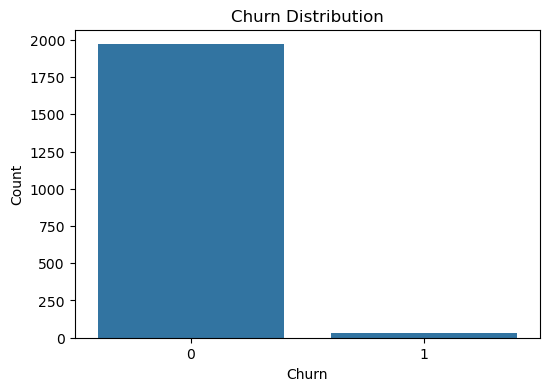

In [16]:
# Visualize distribution of target variable

plt.figure(figsize=(6,4))

sns.countplot(x='churn', data=df)

plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")

plt.show()

In [17]:
#Task 2
df.drop("customer_id", axis=1, inplace=True)

df.head()

,region,plan_type,contract_type,payment_method,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
0,South,Standard,Month-to-month,Debit Card,30,687.40,13,0,0,87.97,8.0,67,0,0,0,0
1,West,Premium,Month-to-month,Wallet,15,1029.74,22,3,1,82.17,5.7,69,0,0,0,0
2,Central,Standard,Month-to-month,Credit Card,72,732.07,13,0,11,89.39,6.4,63,10,0,0,0
3,West,Premium,Month-to-month,Credit Card,22,959.51,19,2,3,139.73,7.2,130,5,0,0,0
4,North,Premium,Month-to-month,Net Banking,11,890.20,18,2,6,156.43,5.8,0,5,1,2,0


In [18]:
categorical_columns = [
    'region',
    'plan_type',
    'contract_type',
    'payment_method'
]

label_encoder = LabelEncoder()

for col in categorical_columns:
    df[col] = label_encoder.fit_transform(df[col])

df.head()

,region,plan_type,contract_type,payment_method,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
0,3,3,0,1,30,687.40,13,0,0,87.97,8.0,67,0,0,0,0
1,4,2,0,4,15,1029.74,22,3,1,82.17,5.7,69,0,0,0,0
2,0,3,0,0,72,732.07,13,0,11,89.39,6.4,63,10,0,0,0
3,4,2,0,0,22,959.51,19,2,3,139.73,7.2,130,5,0,0,0
4,2,2,0,2,11,890.20,18,2,6,156.43,5.8,0,5,1,2,0


In [19]:
X = df.drop("churn", axis=1)

y = df["churn"]

In [20]:
scaler = StandardScaler()

X = scaler.fit_transform(X)

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [23]:
X_test

array([[-1.3945442 , -1.24882019, -0.80824761, ..., -0.43102196,
         0.82075585,  0.0787488 ],
       [-0.00208868,  1.09564825,  0.56632316, ...,  0.89316226,
        -1.21838912,  1.03909998],
       [-0.69831644,  1.09564825, -0.80824761, ..., -1.09311408,
         0.82075585, -0.88160239],
       ...,
       [ 1.39036683,  1.09564825,  0.56632316, ...,  1.55525437,
         0.82075585, -0.88160239],
       [-0.69831644, -1.24882019, -0.80824761, ...,  0.23107015,
        -1.21838912, -0.88160239],
       [-0.69831644,  1.09564825, -0.80824761, ...,  0.23107015,
        -1.21838912, -0.88160239]])

In [24]:
y_test

1860    0
353     0
1333    0
905     0
1289    0
       ..
965     0
1284    0
1739    0
261     0
535     0
Name: churn, Length: 400, dtype: int64

In [25]:
#Task 3
model = MLPClassifier(
    hidden_layer_sizes=(16,8),
    activation='relu',
    solver='adam',
    max_iter=200,
    random_state=42
)

In [26]:
model.fit(X_train, y_train)

C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(hidden_layer_sizes=(16, 8), random_state=42)

In [34]:
#Task 4
y_pred = model.predict(X_test)

In [35]:
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.9825


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\Admin\\results\\evaluation_outputs.png'

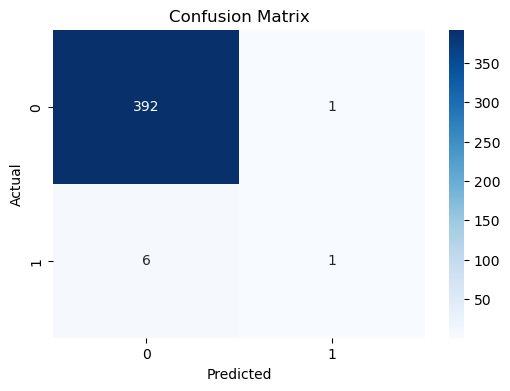

In [49]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("results/evaluation_outputs.png")

plt.show()

In [37]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       393
           1       0.50      0.14      0.22         7

    accuracy                           0.98       400
   macro avg       0.74      0.57      0.61       400
weighted avg       0.98      0.98      0.98       400



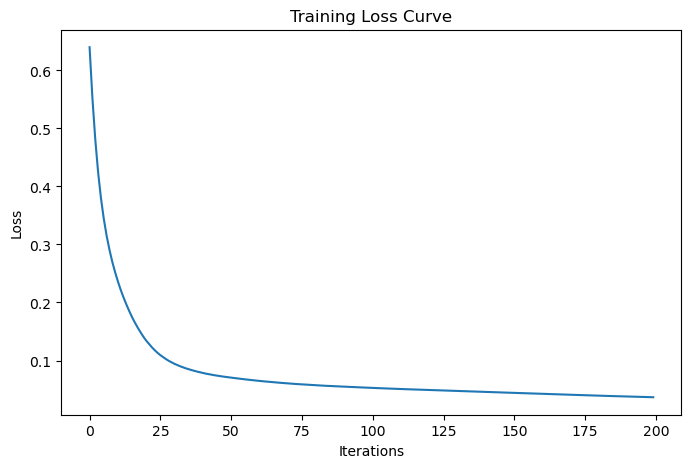

In [38]:
plt.figure(figsize=(8,5))

plt.plot(model.loss_curve_)

plt.title("Training Loss Curve")
plt.xlabel("Iterations")
plt.ylabel("Loss")

plt.show()

In [33]:
#Task 5
# Experiment 1

model1 = MLPClassifier(
    hidden_layer_sizes=(16,8),
    activation='relu',
    max_iter=200,
    random_state=42
)

model1.fit(X_train, y_train)

pred1 = model1.predict(X_test)

acc1 = accuracy_score(y_test, pred1)

print("Experiment 1 Accuracy:", acc1)

Experiment 1 Accuracy: 0.9825


C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [39]:
# Experiment 2

model2 = MLPClassifier(
    hidden_layer_sizes=(32,16),
    activation='relu',
    max_iter=300,
    random_state=42
)

model2.fit(X_train, y_train)

pred2 = model2.predict(X_test)

acc2 = accuracy_score(y_test, pred2)

print("Experiment 2 Accuracy:", acc2)

Experiment 2 Accuracy: 0.975


In [40]:
# Experiment 3

model3 = MLPClassifier(
    hidden_layer_sizes=(64,32),
    activation='tanh',
    max_iter=300,
    random_state=42
)

model3.fit(X_train, y_train)

pred3 = model3.predict(X_test)

acc3 = accuracy_score(y_test, pred3)

print("Experiment 3 Accuracy:", acc3)

Experiment 3 Accuracy: 0.9725


In [41]:
comparison_df = pd.DataFrame({
    "Experiment": ["Experiment 1", "Experiment 2", "Experiment 3"],
    "Hidden Layers": ["(16,8)", "(32,16)", "(64,32)"],
    "Activation": ["relu", "relu", "tanh"],
    "Epochs": [200, 300, 300],
    "Accuracy": [acc1, acc2, acc3]
})

comparison_df

,Experiment,Hidden Layers,Activation,Epochs,Accuracy
0,Experiment 1,"(16,8)",relu,200,0.9825
1,Experiment 2,"(32,16)",relu,300,0.9750
2,Experiment 3,"(64,32)",tanh,300,0.9725


In [42]:
comparison_df.to_csv("model_comparison_table.csv", index=False)

In [43]:
#Task 6
print("""
Weights determine the importance of input features in prediction.
Biases help shift the activation function and improve model flexibility.
""")


Weights determine the importance of input features in prediction.
Biases help shift the activation function and improve model flexibility.



In [44]:
print("""
Activation functions introduce non-linearity into the neural network,
allowing it to learn complex patterns from data.
""")


Activation functions introduce non-linearity into the neural network,
allowing it to learn complex patterns from data.



In [45]:
print("""
A high learning rate may make the model unstable and skip optimal solutions.
A low learning rate makes training slower and less efficient.
""")


A high learning rate may make the model unstable and skip optimal solutions.
A low learning rate makes training slower and less efficient.



In [46]:
print("""
Underfitting occurs when the model is too simple to learn patterns.
Overfitting occurs when the model memorizes training data and performs poorly on new data.
""")


Underfitting occurs when the model is too simple to learn patterns.
Overfitting occurs when the model memorizes training data and performs poorly on new data.

